# Mental Health Sentiment Classification — Transformer Models

**Project Type:** NLP / Mental Health Sentiment Classification

**Notebook Purpose:** Transformer Fine-tuning, Training, Evaluation, and Model Selection

---

## Objective

This notebook develops and evaluates transformer-based language models for
multi-class mental health sentiment classification.

Unlike recurrent neural networks, transformer models leverage self-attention
mechanisms to capture contextual relationships across the entire sentence,
resulting in stronger language understanding and improved classification
performance.

The objectives of this notebook are to:

1. Load the preprocessed dataset.
2. Reproduce the train-validation-test split.
3. Tokenize text using a pretrained transformer tokenizer.
4. Fine-tune a pretrained DeBERTa V3 model.
5. Evaluate the model using multiple classification metrics.
6. Compare transformer performance with previous deep learning models.
7. Select the best-performing transformer model.
8. Save all deployment artifacts for future inference.

In [1]:
# Core Libraries

import random
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Visualization

import matplotlib.pyplot as plt

# PyTorch

import torch
from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# Transformers

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Project Structure

To maintain consistency across all project notebooks, a unified directory
structure is used for storing datasets, trained models, tokenizers,
evaluation results, and deployment artifacts.

Using centralized paths improves project portability and avoids hard-coded
file locations.

In [2]:
from pathlib import Path

# Mount Google Drive (Google Colab only)

try:

    from google.colab import drive

    drive.mount("/content/drive")
    BASE_DIR = Path(
        "/content/drive/MyDrive/Mental_Health_Classification"
    )

except:

    print("Running outside Google Colab...")

    BASE_DIR = Path.cwd()

PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
TOKENIZERS_DIR = PROJECT_DIR / "tokenizers"
ENCODERS_DIR = PROJECT_DIR / "encoders"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
DEPLOYMENT_DIR = PROJECT_DIR / "deployment"

directories = [

    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    TOKENIZERS_DIR,
    ENCODERS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    NOTEBOOKS_DIR,
    DEPLOYMENT_DIR
]

for directory in directories:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project directories are ready.")

Mounted at /content/drive
Project directories are ready.


## 3. Reproducibility

Random seeds are fixed to improve experiment reproducibility whenever
possible.

Although complete determinism cannot always be guaranteed when using GPUs,
setting the random seeds helps produce more consistent training results.

In [3]:
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed : {SEED}")

Random Seed : 42


## 4. Device Configuration

Transformer models benefit significantly from GPU acceleration.

The training process automatically uses CUDA when a compatible GPU is
available; otherwise, training falls back to the CPU.

In [4]:
device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device : {device}")

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

Device : cuda
Tesla T4


## 5. Load the Processed Dataset

The preprocessed dataset generated during the data preprocessing stage is
loaded directly.

Using a single processed dataset ensures that all machine learning, deep
learning, and transformer models are trained on exactly the same data.

In [5]:
DATA_PATH = (

    PROCESSED_DATA_DIR /
    "preprocessed_data.csv"
)
df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(50029, 7)


,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14


## 6. Feature Selection

Transformer models operate directly on minimally processed text.

Unlike classical machine learning and recurrent neural networks, no
additional normalization such as lemmatization or punctuation removal is
performed before tokenization.

The cleaned text generated during preprocessing is therefore used as the
input feature.

In [6]:
X = df["clean_statement"]
y = df["status"]

print(f"Samples : {len(X):,}")
print()
print(y.value_counts())

Samples : 50,029

status
Normal        15925
Depression    15081
Suicidal      10629
Anxiety        3605
Bipolar        2501
Stress         2288
Name: count, dtype: int64


## 7. Load the Label Encoder

The label encoder created during the preprocessing stage is loaded to convert
the target labels into numerical values.

Using the same encoder across all notebooks guarantees consistent label
mapping throughout the project.

In [7]:
LABEL_ENCODER_PATH = (

    ENCODERS_DIR /
    "label_encoder.pkl"
)

label_encoder = joblib.load(
    LABEL_ENCODER_PATH
)

CLASS_NAMES = label_encoder.classes_
NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)
print(f"\nNumber of Classes : {NUM_CLASSES}")

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Stress' 'Suicidal']

Number of Classes : 6


## 8. Train / Validation / Test Split

The dataset is divided into training, validation, and testing subsets.

A stratified split is used to preserve the original class distribution across
all subsets, ensuring a fair evaluation of model performance.

In [8]:
y = label_encoder.transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train
)

print(f"Training Samples   : {len(X_train):,}")
print(f"Validation Samples : {len(X_val):,}")
print(f"Testing Samples    : {len(X_test):,}")

Training Samples   : 36,020
Validation Samples : 4,003
Testing Samples    : 10,006


## 9. Transformer Configuration

The main hyperparameters used during transformer fine-tuning are defined in a
single configuration block.

Keeping these values centralized simplifies experimentation and improves
reproducibility.

In [9]:
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LENGTH = 160
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
EPOCHS = 10
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
PATIENCE = 3

print(f"Model          : {MODEL_NAME}")
print(f"Max Length     : {MAX_LENGTH}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Weight Decay   : {WEIGHT_DECAY}")
print(f"Epochs         : {EPOCHS}")
print(f"Warmup Ratio   : {WARMUP_RATIO}")

Model          : microsoft/deberta-v3-base
Max Length     : 160
Batch Size     : 16
Learning Rate  : 3e-05
Weight Decay   : 0.01
Epochs         : 10
Warmup Ratio   : 0.1


## 10. Tokenization

The pretrained tokenizer converts each sentence into token IDs and attention
masks compatible with the selected transformer architecture.

In [10]:
# Load Tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")
print(f"Tokenizer : {MODEL_NAME}")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Tokenizer loaded successfully.
Tokenizer : microsoft/deberta-v3-base


In [11]:
# Encode Training Data

train_encodings = tokenizer(

    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

In [12]:
# Encode Validation Data

val_encodings = tokenizer(

    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

In [13]:
# Encode Test Data

test_encodings = tokenizer(

    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

In [14]:
print("Tokenization completed.")
print()

print(train_encodings["input_ids"].shape)
print(val_encodings["input_ids"].shape)
print(test_encodings["input_ids"].shape)

Tokenization completed.

torch.Size([36020, 160])
torch.Size([4003, 160])
torch.Size([10006, 160])


## 11. Build Datasets

The tokenized inputs and encoded labels are converted into PyTorch datasets
and data loaders for efficient mini-batch training and evaluation.

In [15]:
# Convert Labels

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [16]:
# Create TensorDatasets

train_dataset = TensorDataset(

    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    y_train_tensor
)

val_dataset = TensorDataset(

    val_encodings["input_ids"],
    val_encodings["attention_mask"],
    y_val_tensor
)

test_dataset = TensorDataset(

    test_encodings["input_ids"],
    test_encodings["attention_mask"],
    y_test_tensor
)

In [17]:
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

In [18]:
print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

Training Batches   : 2252
Validation Batches : 251
Testing Batches    : 626


## 12. Training Configuration

The transformer model, loss function, optimizer, learning-rate scheduler,
mixed precision training, and class weighting are configured before training.

These settings improve training stability, reduce overfitting, and help the
model learn effectively from the imbalanced dataset.

In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    torch_dtype=torch.float32
)

model.to(device)

print("Model loaded successfully.")

# Optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

# CUDA Optimizations

if torch.cuda.is_available():

    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

MAX_GRAD_NORM = 1.0

best_f1 = 0.0
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_weighted_f1": [],
    "val_weighted_f1": [],
    "train_macro_f1": [],
    "val_macro_f1": []
}

print("Training configuration completed.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

Model loaded successfully.
Training configuration completed.


## 13. Training Functions

The transformer model is trained and validated using custom training loops.

Separate functions are implemented for training and validation to improve code
readability, simplify experimentation, and enable detailed performance
monitoring after every epoch.

In [20]:
from tqdm.auto import tqdm

In [21]:
# Training Function
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    predictions = []
    labels = []

    start_time = time.time()

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for input_ids, attention_mask, targets in progress_bar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=targets
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
            )

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)

        predictions.extend(preds.cpu().numpy())
        labels.extend(targets.cpu().numpy())

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    metrics = {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "time": time.time() - start_time
    }

    return metrics


In [22]:
import torch

# Validation Function

def validate(model, loader):

    model.eval()
    total_loss = 0
    predictions = []
    labels = []

    start_time = time.time()

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    with torch.no_grad():
        for input_ids, attention_mask, targets in progress_bar:

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            targets = targets.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=targets
                )

            loss = outputs.loss
            preds = outputs.logits.argmax(dim=1)

            total_loss += loss.item()
            predictions.extend(
                preds.cpu().numpy()
            )

            labels.extend(
                targets.cpu().numpy()
            )

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    metrics = {

        "loss":
            total_loss / len(loader),

        "accuracy":

            accuracy_score(
                labels,
                predictions
            ),

        "precision":

            precision_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "recall":

            recall_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "weighted_f1":

            f1_score(
                labels,
                predictions,
                average="weighted",
                zero_division=0
            ),

        "macro_f1":

            f1_score(
                labels,
                predictions,
                average="macro",
                zero_division=0
            ),

        "time":
            time.time() - start_time
    }
    return metrics

## 14. Model Training

The transformer model is fine-tuned over multiple epochs while monitoring
validation performance after every epoch.

The checkpoint achieving the highest validation Weighted F1-score is saved,
while Early Stopping terminates training automatically when validation
performance no longer improves.

In [23]:
# Initialize Training

BEST_MODEL_PATH = MODELS_DIR / "best_deberta_v3.pt"
best_f1 = 0.0
patience_counter = 0
training_start_time = time.time()

In [ ]:
# Training Loop

for epoch in range(EPOCHS):

    print()
    print("=" * 70)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 70)

    train_metrics = train_epoch(

        model,
        train_loader
    )

    val_metrics = validate(

        model,
        val_loader
    )

    history["train_loss"].append(

        train_metrics["loss"]
    )

    history["val_loss"].append(

        val_metrics["loss"]
    )

    history["train_accuracy"].append(

        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(

        val_metrics["accuracy"]
    )

    history["train_precision"].append(

        train_metrics["precision"]
    )

    history["val_precision"].append(

        val_metrics["precision"]
    )

    history["train_recall"].append(

        train_metrics["recall"]
    )

    history["val_recall"].append(

        val_metrics["recall"]
    )

    history["train_weighted_f1"].append(

        train_metrics["weighted_f1"]
    )

    history["val_weighted_f1"].append(

        val_metrics["weighted_f1"]
    )

    history["train_macro_f1"].append(

        train_metrics["macro_f1"]
    )

    history["val_macro_f1"].append(

        val_metrics["macro_f1"]
    )

    print(f"Train Loss       : {train_metrics['loss']:.4f}")
    print(f"Validation Loss  : {val_metrics['loss']:.4f}")
    print()
    print(f"Train Accuracy   : {train_metrics['accuracy']:.4f}")
    print(f"Validation Acc.  : {val_metrics['accuracy']:.4f}")
    print()
    print(f"Train Weighted F1 : {train_metrics['weighted_f1']:.4f}")
    print(f"Validation F1     : {val_metrics['weighted_f1']:.4f}")
    print()
    print(f"Training Time    : {train_metrics['time']:.2f} sec")
    print(f"Validation Time  : {val_metrics['time']:.2f} sec")

    if val_metrics["weighted_f1"] > best_f1:

        best_f1 = val_metrics["weighted_f1"]
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print()
        print("Best model updated.")

    else:

        patience_counter += 1
        print()

        print(
            f"No improvement ({patience_counter}/{PATIENCE})"
        )

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping triggered.")
        break


Epoch 1/10


Training:   0%|          | 0/2252 [00:00<?, ?it/s]

Validation:   0%|          | 0/251 [00:00<?, ?it/s]

Train Loss       : 0.7687
Validation Loss  : 0.5235

Train Accuracy   : 0.6943
Validation Acc.  : 0.7879

Train Weighted F1 : 0.6815
Validation F1     : 0.7794

Training Time    : 1414.38 sec
Validation Time  : 50.42 sec

Best model updated.

Epoch 2/10


Training:   0%|          | 0/2252 [00:00<?, ?it/s]

...

Train Loss       : 0.2659
Validation Loss  : 0.4968

Train Accuracy   : 0.8974
Validation Acc.  : 0.8346

Train Weighted F1 : 0.8975
Validation F1     : 0.8342

Training Time    : 1413.44 sec
Validation Time  : 50.37 sec

Best model updated.

Epoch 5/10


Training:   0%|          | 0/2252 [00:00<?, ?it/s]

Validation:   0%|          | 0/251 [00:00<?, ?it/s]

Train Loss       : 0.1976
Validation Loss  : 0.6159

Train Accuracy   : 0.9303
Validation Acc.  : 0.8261

Train Weighted F1 : 0.9303
Validation F1     : 0.8224

Training Time    : 1413.65 sec
Validation Time  : 50.53 sec

No improvement (1/3)

Epoch 6/10


Training:   0%|          | 0/2252 [00:00<?, ?it/s]

## 15. Load the Best Model

The checkpoint with the highest validation Weighted F1-score is restored
before evaluating the model on the unseen test dataset.

In [24]:
model.load_state_dict(

    torch.load(

        BEST_MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


## 16. Evaluate on Test Set

The best-performing DeBERTa model is evaluated on the unseen test dataset.

Multiple evaluation metrics are computed to measure the model's overall
classification performance and provide a fair comparison with the previous
machine learning and deep learning models.

In [25]:
def evaluate(model, loader):

    model.eval()

    predictions = []
    labels = []

    total_loss = 0

    with torch.no_grad():

        for input_ids, attention_mask, targets in tqdm(
            loader,
            desc="Testing",
            leave=False
        ):

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            targets = targets.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=targets
            )

            loss = outputs.loss

            total_loss += loss.item()

            preds = outputs.logits.argmax(dim=1)

            predictions.extend(
                preds.cpu().numpy()
            )

            labels.extend(
                targets.cpu().numpy()
            )

    metrics = {

        "loss": total_loss / len(loader),

        "accuracy": accuracy_score(
            labels,
            predictions
        ),

        "precision": precision_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "recall": recall_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }

    return metrics, labels, predictions

In [26]:
test_metrics, y_true, y_pred = evaluate(

    model,
    test_loader
)

print("=" * 60)
print("Test Performance")
print("=" * 60)

for metric, value in test_metrics.items():

    print(f"{metric:<15}: {value:.4f}")

Testing:   0%|          | 0/626 [00:00<?, ?it/s]

Test Performance
loss           : 0.4935
accuracy       : 0.8404
precision      : 0.8408
recall         : 0.8404
weighted_f1    : 0.8401
macro_f1       : 0.8305


In [36]:
accuracy = test_metrics["accuracy"]
precision = test_metrics["precision"]
recall = test_metrics["recall"]
weighted_f1 = test_metrics["weighted_f1"]
macro_f1 = test_metrics["macro_f1"]

## 17. Classification Report

A detailed classification report is generated to evaluate the performance of
the transformer model for each mental health class individually.

The report includes precision, recall, F1-score, and support, providing a
comprehensive view of strengths and weaknesses across all categories.

In [27]:
report = classification_report(

    y_true,
    y_pred,

    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

     Anxiety     0.8610    0.9196    0.8893       721
     Bipolar     0.8668    0.8200    0.8428       500
  Depression     0.7716    0.8110    0.7908      3016
      Normal     0.9704    0.9564    0.9633      3185
      Stress     0.7627    0.7860    0.7742       458
    Suicidal     0.7487    0.6980    0.7225      2126

    accuracy                         0.8404     10006
   macro avg     0.8302    0.8318    0.8305     10006
weighted avg     0.8408    0.8404    0.8401     10006



## 18. Confusion Matrix

The confusion matrix visualizes the model's predictions against the true
labels, helping identify common misclassification patterns between mental
health categories.

This visualization complements the numerical evaluation metrics by providing
an intuitive overview of classification performance.

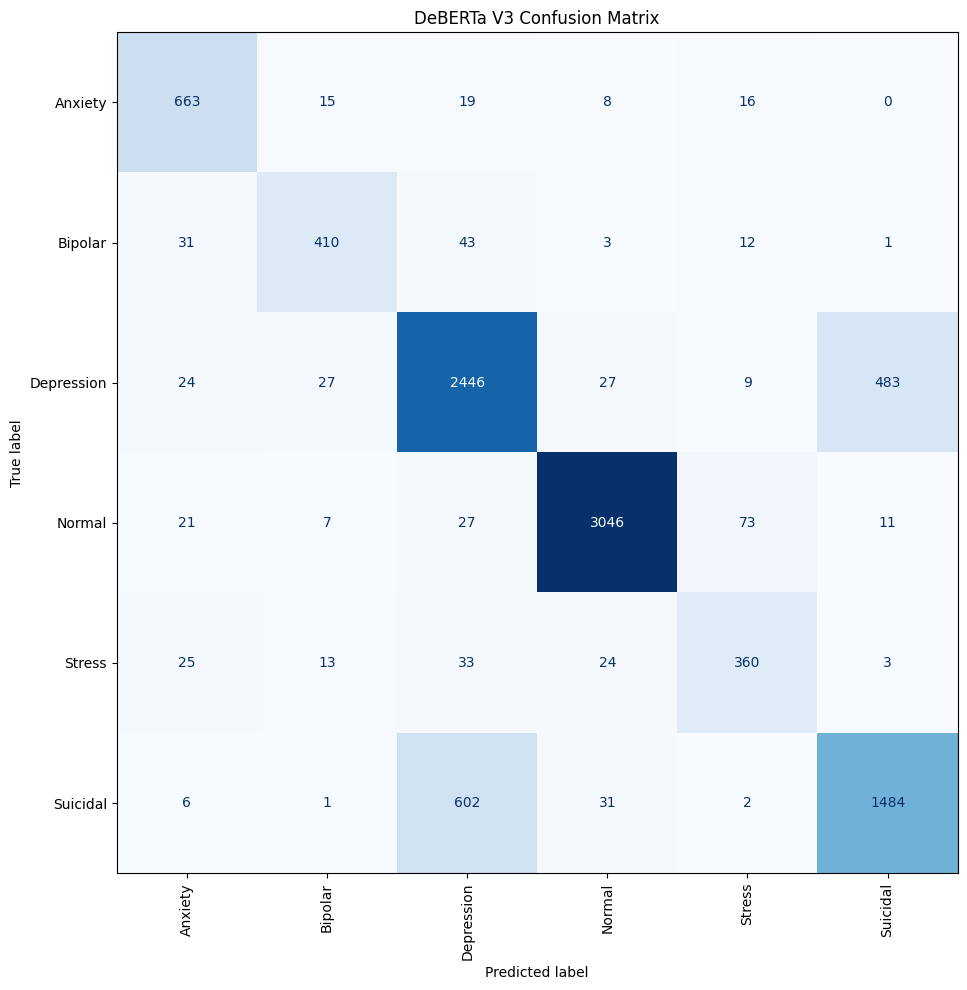

In [28]:
fig, ax = plt.subplots(

    figsize=(12, 10)
)

ConfusionMatrixDisplay.from_predictions(

    y_true,
    y_pred,

    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False,
    ax=ax
)

plt.title("DeBERTa V3 Confusion Matrix")
plt.tight_layout()
plt.show()

## 19. Learning Curves

Training history is visualized to examine convergence behavior and monitor
potential overfitting during fine-tuning.

Both loss and Weighted F1-score are displayed across all training epochs.

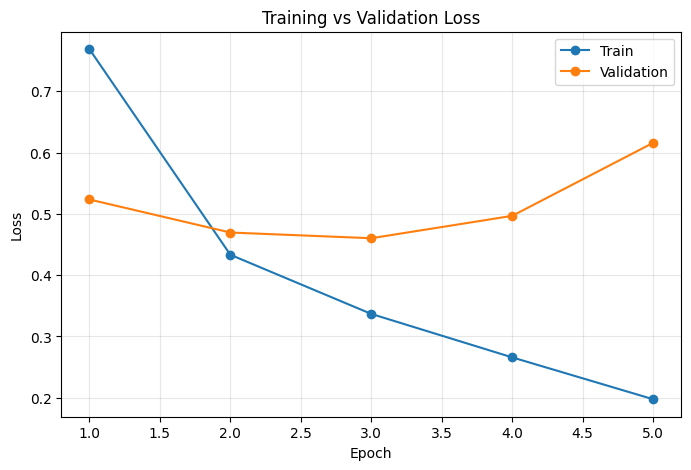

In [42]:
# Loss Curve

plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

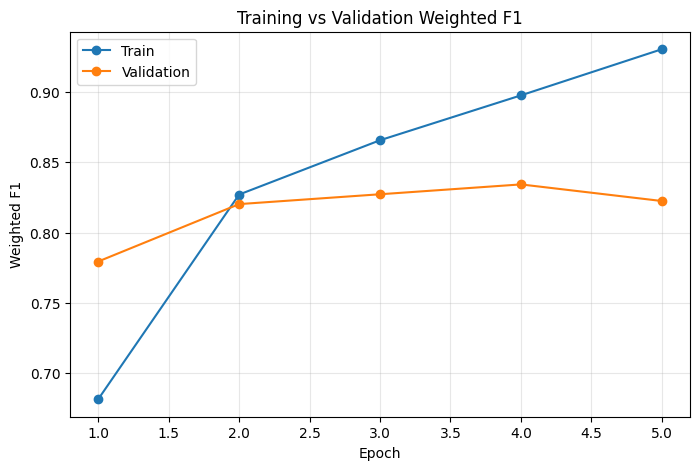

In [44]:
# Weighted F1 Curve

plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_weighted_f1"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_weighted_f1"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted F1")
plt.title("Training vs Validation Weighted F1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

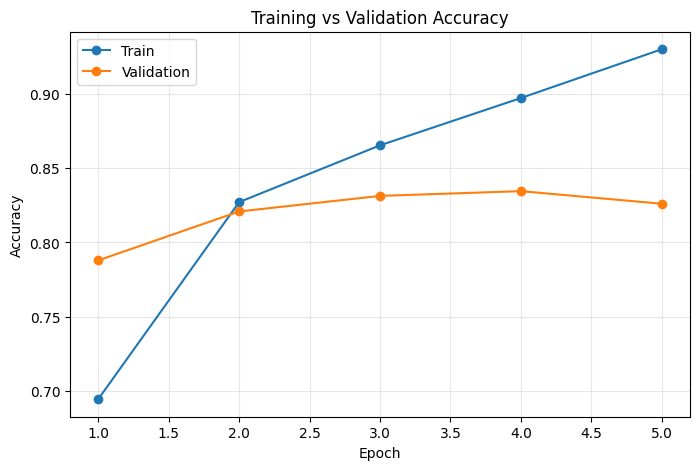

In [43]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 20. Sample Predictions

A small subset of test samples is displayed to qualitatively inspect the
predictions generated by the fine-tuned transformer model.

Reviewing individual predictions provides additional insight into model
behavior beyond aggregate evaluation metrics and helps identify common
classification patterns.

In [32]:
results_df = pd.DataFrame({

    "Text": X_test.reset_index(drop=True),
    "True Label": label_encoder.inverse_transform(y_true),
    "Predicted Label": label_encoder.inverse_transform(y_pred)

})

results_df["Correct"] = (

    results_df["True Label"] ==
    results_df["Predicted Label"]
)

results_df.sample(

    15,
    random_state=SEED
)

,Text,True Label,Predicted Label,Correct
8324,Time to fly! Ord-dca-ord-clt 16hrs clt-ord-iad...,Normal,Normal,True
3635,2 weeks until the exam and already starting to...,Anxiety,Anxiety,True
9377,my mind is destroying me. i want to live and i...,Suicidal,Suicidal,True
4896,If anyoneseemesleepingbehind theMichaeldArtsan...,Depression,Suicidal,False
8441,going back to straighten my hair download some...,Normal,Normal,True
952,hi reddit i m not sure who else to turn to a i...,Depression,Depression,True
8875,"Since late 2018 to now, I have been battling w...",Depression,Depression,True
3263,No I am not doing okay and have not been for a...,Suicidal,Suicidal,True
3025,Pickaw isn't on my side,Normal,Normal,True
4395,"I never wanted to stand out, to be the center ...",Depression,Depression,True


## 21. Misclassified Samples

Incorrectly classified samples are extracted to better understand the
limitations of the transformer model.

Analyzing these examples can reveal ambiguous sentences, overlapping
categories, or potential areas for future model improvement.

In [33]:
errors_df = results_df.loc[

    results_df["Correct"] == False
]

print(

    f"Misclassified Samples : {len(errors_df):,}"
)

errors_df.sample(

    20,
    random_state=SEED
)

Misclassified Samples : 1,597


,Text,True Label,Predicted Label,Correct
5024,I really do not give a shit anymore. I do not ...,Suicidal,Depression,False
739,I have dealt with my own mental health issues ...,Suicidal,Depression,False
2143,Idk if it is just me but all my life I felt li...,Suicidal,Depression,False
4184,Another day wasted in bed. I guess doing nothi...,Suicidal,Depression,False
8405,Seroquel gives me bad trips? I have major depr...,Depression,Bipolar,False
7066,As you guys can read i am done with everything...,Depression,Suicidal,False
9413,"The fact is that it is not very common, these ...",Stress,Suicidal,False
4304,Well me I am not that type person to talk abt ...,Depression,Suicidal,False
3644,I do not know what I did wrong. She never admi...,Depression,Suicidal,False
9319,"His reply: ""Thanks for not punching me!"" All-i...",Normal,Stress,False


## 22. Save Training History

Training history is exported to facilitate future analysis, visualization,
and experiment tracking without retraining the model.

In [34]:
history_df = pd.DataFrame(history)

history_path = (

    RESULTS_DIR /
    "deberta_training_history.csv"
)

history_df.to_csv(

    history_path,
    index=False
)

print(history_path)

/content/drive/MyDrive/Mental_Health_Classification/results/deberta_training_history.csv


## 23. Save Evaluation Metrics

The final evaluation metrics are saved for future comparison with other
machine learning and deep learning models.

In [45]:
metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "Weighted F1",
        "Macro F1"
    ],

    "Score": [

        accuracy,
        precision,
        recall,
        weighted_f1,
        macro_f1
    ]

})

metrics_path = (

    RESULTS_DIR /
    "deberta_metrics.csv"
)

metrics_df.to_csv(

    metrics_path,
    index=False
)

metrics_df

,Metric,Score
0,Accuracy,0.840396
1,Precision,0.840812
2,Recall,0.840396
3,Weighted F1,0.840141
4,Macro F1,0.830485


## 24. Save Classification Report

The detailed classification report is exported as a text file for future
reference and model comparison.

In [46]:
report_path = (

    RESULTS_DIR /
    "deberta_classification_report.txt"
)

with open(

    report_path,
    "w",
    encoding="utf-8"

) as f:

    f.write(report)

print(report_path)

/content/drive/MyDrive/Mental_Health_Classification/results/deberta_classification_report.txt


## 25. Save Predictions

Model predictions on the test set are stored to support further error
analysis and qualitative inspection.

In [47]:
predictions_path = (

    RESULTS_DIR /
    "deberta_predictions.csv"
)

results_df.to_csv(

    predictions_path,
    index=False
)

print(predictions_path)

/content/drive/MyDrive/Mental_Health_Classification/results/deberta_predictions.csv


## 26. Export Deployment Artifacts

The final deployment artifacts are exported to simplify model serving and
production deployment.

Saving the model, tokenizer, label encoder, and configuration separately
allows inference applications such as FastAPI, Streamlit, or Docker services
to load the trained model without requiring any retraining.

In [48]:
tokenizer.save_pretrained(

    TOKENIZERS_DIR / "deberta_v3"
)
print("Tokenizer saved successfully.")

joblib.dump(

    label_encoder,
    DEPLOYMENT_DIR / "label_encoder.pkl"

)
print("Label Encoder saved.")

Tokenizer saved successfully.
Label Encoder saved.


In [49]:
import json

deployment_config = {

    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES.tolist()
}

config_path = (

    DEPLOYMENT_DIR /
    "config.json"
)

with open(

    config_path,
    "w",
    encoding="utf-8"

) as f:

    json.dump(

        deployment_config,
        f,
        indent=4
    )

print(config_path)

/content/drive/MyDrive/Mental_Health_Classification/deployment/config.json


In [50]:
import shutil

deployment_model_path = (

    DEPLOYMENT_DIR /
    "best_deberta_v3.pt"
)

shutil.copy(

    BEST_MODEL_PATH,
    deployment_model_path
)
print("Model copied successfully.")

Model copied successfully.


In [51]:
deployment_tokenizer = (

    DEPLOYMENT_DIR /
    "tokenizer"
)

tokenizer.save_pretrained(
    deployment_tokenizer
)
print("Tokenizer copied successfully.")

Tokenizer copied successfully.


In [52]:
print("Deployment Files")
print("-" * 40)

for file in sorted(

    DEPLOYMENT_DIR.iterdir()
):
    print(file.name)

Deployment Files
----------------------------------------
best_deberta_v3.pt
config.json
dl_config.pkl
label_encoder.pkl
tokenizer
